# This is exploratory data analysis of data generated by APSCHE-British Council programme. Data involves pre-assessment tests(OPT) and final-assessment(APTIS) tests. 

In [149]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')
import re

<Figure size 640x480 with 0 Axes>

<b>OPT stands for Online Placement Test</b>, which is a pre-assessment test taken to understand the learning levels of students beore imparting the training. It has following important characteristics - 
1. It is a 40 min test
2. At the end of the test each student received CEFR (Common European Framework) grade between 
    - <b>A0 (Beginner)
    - A1 (Elementary)
    - A2 (Pre-Intermediate)
    - B1-B2 (Intermediate)</b>

In [282]:
#OPT Data.
# It has students details, their college name (in HomeDomain column), Status (Completed or Incomplete), Date enrolled
# Completed Date and CEFR level 
opt_report = pd.read_csv('opt_report.csv')
opt_report = opt_report.rename(columns = {'AP NT CEFR level':'CEFR_grade'})

<B>How many students successfully completed OPT exam?</B>

In [3]:
opt_report_completed = opt_report[opt_report['Status'] == 'Completed']
# There are still some rows with status as Completed but CEFR grade is NaN. We will remove those rows altogether
# as students don't have grades.
opt_report_completed = opt_report_completed.dropna()
opt_report_completed.shape

(31599, 8)

<b>31599 students overall completed OPT test</b>

<b>Distribution of OPT scores? </b>

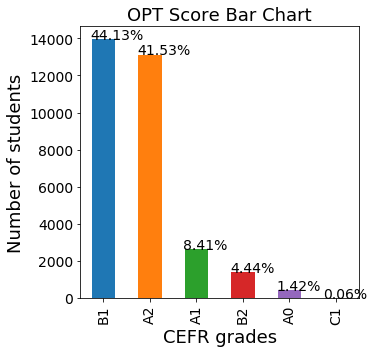

In [73]:
total_students = sum(opt_report_completed['CEFR_grade'].value_counts())
opt_bar_plot = opt_report_completed['CEFR_grade'].value_counts().plot(kind='bar', fontsize = 14, figsize = (5,5))
opt_bar_plot.set_xlabel('CEFR grades', fontsize = 18)
opt_bar_plot.set_ylabel('Number of students', fontsize = 18)
opt_bar_plot.set_title('OPT Score Bar Chart', fontsize = 18)
for i in opt_bar_plot.patches:
    opt_bar_plot.text(i.get_x() - 0.03, i.get_height() + 5.0, str(round((i.get_height()/total_students)*100, 2))+'%', fontsize = 14, color = 'black')

<h3> OPT scores analysis</h3>
<h4>As visible more than 44% of the students scored B1 which is intermediate score and more than 41% of the students scored A2 which is pre-intermediate score.
Generalising for all enrolled students, we can safely assume that more than 80% of our population was in A2 & B1 (CEFR grades)range before and after the training. </h4>

<h2>APTIS(post training assessment test) scores Analysis</h2>

APTIS is a 40 min exam consisting of 2 sections 
 - Grammar & Vocabulary
 - Speaking

In [257]:
aptis_report = pd.read_csv('aptis_report.csv')
#We are only concerned with APTIS grades at this point and not with Raw Scores (Reduces complexity as well).
aptis_report.drop(['Raw Score', 'Test Name'], axis=1, inplace=True)
aptis_report = aptis_report.dropna()
aptis_report_final = aptis_report

<h3>As visible above, following columns are available in processed APTIS scores dataframe</h3>
 - Full Name of the students
 - Test Centre which is same as the college
 - Raw Score - (This is the total score obtained in both the sections)
 - CEFR Grade (This is the final grade of the student)

<B>How many students successfully completed APTIS exam (as of January 20th 2019)?</B>

In [258]:
aptis_report_final.shape

(21409, 4)

<b>21,409 students overall have completed APTIS test till now</b>

<b>Distribution of APTIS scores? </b>

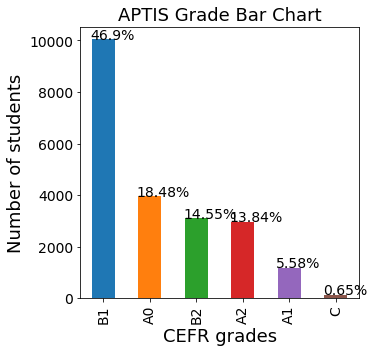

In [259]:
total_students_aptis = sum(aptis_report_final['CEFR Grade'].value_counts())
aptis_bar_plot = aptis_report_final['CEFR Grade'].value_counts().plot(kind='bar', fontsize = 14, figsize = (5,5))
aptis_bar_plot.set_xlabel('CEFR grades', fontsize = 18)
aptis_bar_plot.set_ylabel('Number of students', fontsize = 18)
aptis_bar_plot.set_title('APTIS Grade Bar Chart', fontsize = 18)
for i in aptis_bar_plot.patches:
    aptis_bar_plot.text(i.get_x() - 0.03, i.get_height() + 5.0, str(round((i.get_height()/total_students_aptis)*100, 2))+'%', fontsize = 14, color = 'black')

<h3>More than 46% of 22000 students have scored B1 grade. Furthermore, remaining 50%(approx.) is almost equally divided in A0, B2, A2 respectively</h3>

<h3>Comparative analysis of bar charts of OPT and APTIS</h3>

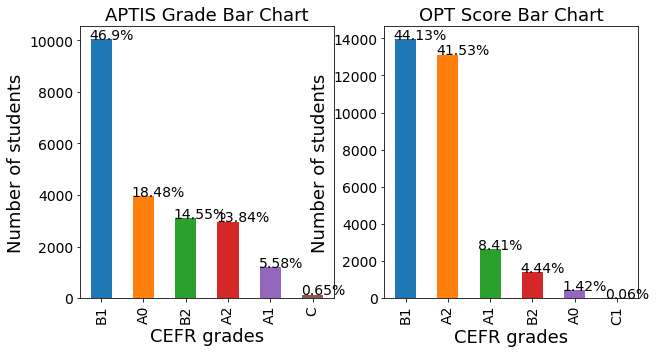

In [260]:
#<TODO:>Reptition of code to generate OPT and APTIS graph side by side for time being till I find a fix to show both graphs side by side.

fig, axs = plt.subplots(1,2)    
total_students_aptis = sum(aptis_report_final['CEFR Grade'].value_counts())
aptis_bar_plot = aptis_report_final['CEFR Grade'].value_counts().plot(kind='bar', fontsize = 14, figsize = (10,5), ax=axs[0])
aptis_bar_plot.set_xlabel('CEFR grades', fontsize = 18)
aptis_bar_plot.set_ylabel('Number of students', fontsize = 18)
aptis_bar_plot.set_title('APTIS Grade Bar Chart', fontsize = 18)
for i in aptis_bar_plot.patches:
    aptis_bar_plot.text(i.get_x() - 0.03, i.get_height() + 5.0, str(round((i.get_height()/total_students_aptis)*100, 2))+'%', fontsize = 14, color = 'black')

    
#<TODO:>Reptition of code to generate OPT graph here for time being till I find a fix to show both graphs side by side.
total_students_opt = sum(opt_report_completed['CEFR_grade'].value_counts())
opt_bar_plot = opt_report_completed['CEFR_grade'].value_counts().plot(kind='bar', fontsize = 14, figsize = (10,5), ax=axs[1])
opt_bar_plot.set_xlabel('CEFR grades', fontsize = 18)
opt_bar_plot.set_ylabel('Number of students', fontsize = 18)
opt_bar_plot.set_title('OPT Score Bar Chart', fontsize = 18)
for i in opt_bar_plot.patches:
    opt_bar_plot.text(i.get_x() - 0.03, i.get_height() + 5.0, str(round((i.get_height()/total_students_opt)*100, 2))+'%', fontsize = 14, color = 'black')

<h3>As we juxtapose the bar graphs of OPT (Pre-assessment test) and APTIS (Final test) side by side, we come to following conclusion</h3>
- Almost half of the population still remains in B1 grade.
- IN OPT (Pre-assessment test) the other half (almost) had majorly A2 grade. However, in APTIS (Final test) other half is almost equally divided into A0,B2,A2- 
  - A0 (This is a lower grade than A2. This could be explained as some of the students who were not part of OPT pre-assesment test or training were allowed to given test)
  - A2 (This is the same grade as A2. This population has either not benefitted from training or like above, they also were not part of OPT and training)
  - B2 (This populations shows much improvement with grade improvement from A2 to B2)
  
<b>Note: There is almost 10 times increase in number of C grades (highest grade) from 0.06% to 0.65%</b>

<h2>Removing Noise from Signal</h2>
It is difficult to ascertain the efficacy of this programme by comparing overall OPT and APTIS results because many of the colleges did not complete all or majority of the components of the programme.
Hence, we will look at the 13 colleges who have completed this programme diligently.

<h2>Following are the 13 colleges which had completed OPT, had shown strong interest in training and have complete the APTIS. We should analyse the OPT and APTIS bar graphs for these colleges separately  to get better idea of the effect of training on students where program was conducted in the best possible way.</h2>
1. SV College Engineering (Tirupati, Chittoor)
2. Andhra Loyola Institute of Engineering and Technology (Vijayawada, Krishna)
3. Sree Vidyanikethan Engineering College (Tirupati, Chittoor)
4. S.R.K.R.Engineering College (Bhimavaram, West Godavari)
5. Ramachandra College of Engineering (Eluru, West Godavari)
6. Swarnandhra College of Engineering and Technology (Narasapur, West Godavari)
7. Dhanekula Institute of Engineering andTechnology (Vijayawada, Krishna)
8. Bapatla Engineering College (Bapatla, Guntur)
9. Bapatla Women’s Engineering College (Bapatla, Guntur)
10. DVR and Dr HS MIC College Of Technology (Kanchikacherla, Krishna)
11. Sri Padmavati Mahila Visvavidyalayam (Tirupati, Chittoor)
12. Pragati Engiineering College (Surampalem, East Godavari)
13. RVR and JC College of Engineering (Chowdavaram, Guntur)

In [261]:
best_colleges = ['SV College of Engineering', 'Andhra Loyola Institute of Engineering and Technology', 'Sree Vidyanikethan Engineering College',\
                'S.R.K.R. Engineering College', 'Swarnandhra College of Engineering and Technology', 'Ramachandra College of Engineering', \
                'Dhanekula Institute of Engineering and Technology',\
                'Bapatla Engineering College', 'Bapatla Womens Engineering College', 'DVR and Dr HS MIC College Of Technology', 'Sri Padmavati Mahila Visvavidyalayam',\
                'Pragati Engiineering College', 'RVR and JC College of Engineering']
best_colleges = [x.replace('.','').strip().lower() for x in best_colleges]
best_colleges

['sv college of engineering',
 'andhra loyola institute of engineering and technology',
 'sree vidyanikethan engineering college',
 'srkr engineering college',
 'swarnandhra college of engineering and technology',
 'ramachandra college of engineering',
 'dhanekula institute of engineering and technology',
 'bapatla engineering college',
 'bapatla womens engineering college',
 'dvr and dr hs mic college of technology',
 'sri padmavati mahila visvavidyalayam',
 'pragati engiineering college',
 'rvr and jc college of engineering']

In [283]:
#OPT data for 13 colleges.
opt_best_colleges = opt_report_completed
opt_best_colleges['HomeDomain'].replace(to_replace=r'\(.+\)', value='',inplace=True,regex=True)
opt_best_colleges['HomeDomain'] = opt_best_colleges['HomeDomain'].apply(lambda x: x.replace('.','').strip().lower())
#Bug fix (missing space) for SRKR engineering college.
opt_best_colleges['HomeDomain'].replace('srkrengineering college', 'srkr engineering college', inplace=True)
opt_best_colleges = opt_best_colleges[opt_best_colleges['HomeDomain'].isin(best_colleges)]
opt_best_colleges.shape

#Tests Start
#print(opt_best_colleges[opt_best_colleges['HomeDomain'] == 'srkr engineering college'])
#print(opt_best_colleges[opt_best_colleges['HomeDomain'] == 'dvr and dr hs mic college of technology'])
#print(opt_best_colleges[opt_best_colleges['HomeDomain'] == 'rvr and jc college of engineering'])
#Tests End

(5968, 8)

<h2>As visible above there are total 5968 students who took OPT (pre-assessment test) from above identified 13 colleges. </h2>

In [285]:
#APTIS data for 13 colleges.
aptis_best_colleges = aptis_report_final
aptis_best_colleges['Test Centre'] = aptis_best_colleges['Test Centre'].apply(lambda x: x.replace('.','').strip().lower())
aptis_best_colleges = aptis_best_colleges[aptis_best_colleges['Test Centre'].isin(best_colleges)]
aptis_best_colleges.shape

#Tests Start
#print(aptis_best_colleges[aptis_best_colleges['Test Centre'] == 'srkr engineering college'])
#print(aptis_best_colleges[aptis_best_colleges['Test Centre'] == 'dvr and dr hs mic college of technology'])
#print(aptis_best_colleges[aptis_best_colleges['Test Centre'] == 'rvr and jc college of engineering'])
#Tests End

(4942, 4)

<h2>As visible above there are total 4942 students who took APTIS (final test) from above identified 13 colleges. </h2>

<h2>Comparative analysis of grades in OPT and in APTIS for students from 13 colleges mentioned above</h2>

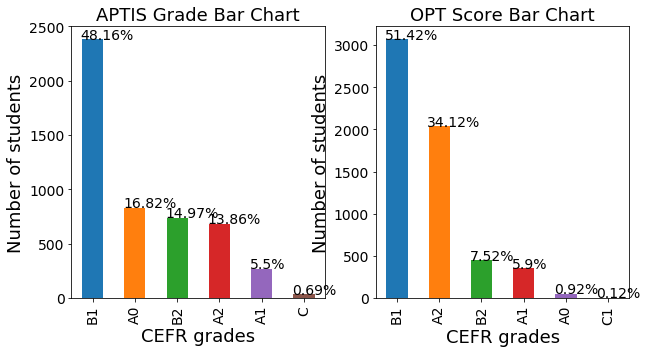

In [281]:
fig, axs = plt.subplots(1,2)    
best_colleges_total_students_aptis = sum(aptis_best_colleges['CEFR Grade'].value_counts())
best_aptis_bar_plot = aptis_best_colleges['CEFR Grade'].value_counts().plot(kind='bar', fontsize = 14, figsize = (10,5), ax=axs[0])
best_aptis_bar_plot.set_xlabel('CEFR grades', fontsize = 18)
best_aptis_bar_plot.set_ylabel('Number of students', fontsize = 18)
best_aptis_bar_plot.set_title('APTIS Grade Bar Chart', fontsize = 18)
for i in best_aptis_bar_plot.patches:
    best_aptis_bar_plot.text(i.get_x() - 0.03, i.get_height() + 5.0, str(round((i.get_height()/best_colleges_total_students_aptis)*100, 2))+'%', fontsize = 14, color = 'black')

    
best_colleges_total_students_opt = sum(opt_best_colleges['CEFR_grade'].value_counts())
best_opt_bar_plot = opt_best_colleges['CEFR_grade'].value_counts().plot(kind='bar', fontsize = 14, figsize = (10,5), ax=axs[1])
best_opt_bar_plot.set_xlabel('CEFR grades', fontsize = 18)
best_opt_bar_plot.set_ylabel('Number of students', fontsize = 18)
best_opt_bar_plot.set_title('OPT Score Bar Chart', fontsize = 18)
for i in best_opt_bar_plot.patches:
    best_opt_bar_plot.text(i.get_x() - 0.03, i.get_height() + 5.0, str(round((i.get_height()/best_colleges_total_students_opt)*100, 2))+'%', fontsize = 14, color = 'black')

<h2>Efficacy of the British Council Programme</h2>

Aforementioned 13 colleges belong to the group of colleges who duly completed all or majority of the components of the programme i.e. OPT, Online & Offline training, APTIS test.
We can conclude the following for these colleges and subsequently, about the efficacy of the programme - 
 - Almost half of the students in these colleges have remained in B1 grade
 - In OPT, the other half were mostly in A2 grade (34%).
 - However, in APTIS, the remaining half are almost equally distributed in grades A0,A2,B2. This shows that while some students have improved their grades from A2 to B2, others have mostly remainied same or decreased their grade.
 
 Note: While percentage is really small, there is 6 times increase in C grade (best grade) from OPT to APTIS.

<h3>As per the overall results and results of the most efficient colleges, there is no clear signal of grade improvement in the students even for the most efficient colleges.

<h4>Disclaimer : Above report is my personal analysis and doesn't reflect the views of my employer, British Council or any other organisation.</h4>